In [9]:
import numpy as np
import pandas as pd
pulsar_name = "J1312+0051"
df = pd.read_pickle(f"../outlier_results/{pulsar_name}/{pulsar_name}-numpyro-checkpoint.pickle")
df_samples = pd.read_feather(f"../outlier_results/{pulsar_name}/{pulsar_name}-numpyro-samples.feather")

In [10]:
df_alpha = df_samples.filter(like="z")

In [11]:
import matplotlib.pyplot as plt
import sys
import discovery as ds
sys.path.append("../modules")
import utils as ou

In [12]:
# read in pulsar data ToAs

psrfile = [f for f in ou.ng20_v1p1_pulsar_files if pulsar_name in f.name]

psr = ds.Pulsar.read_feather(psrfile[0])


In [13]:
toas = psr.toas
residuals = psr.residuals

In [14]:
df_alpha

,z_i_0,z_i_1,z_i_2,z_i_3,z_i_4,z_i_5,z_i_6,z_i_7,z_i_8,z_i_9,...,z_i_1687,z_i_1688,z_i_1689,z_i_1690,z_i_1691,z_i_1692,z_i_1693,z_i_1694,z_i_1695,z_i_1696
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
196,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
197,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
198,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Outlier indices: []


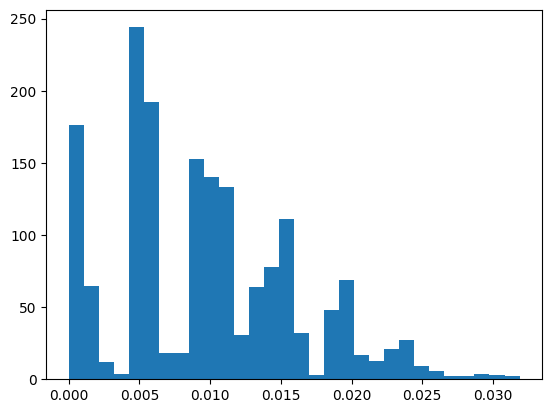

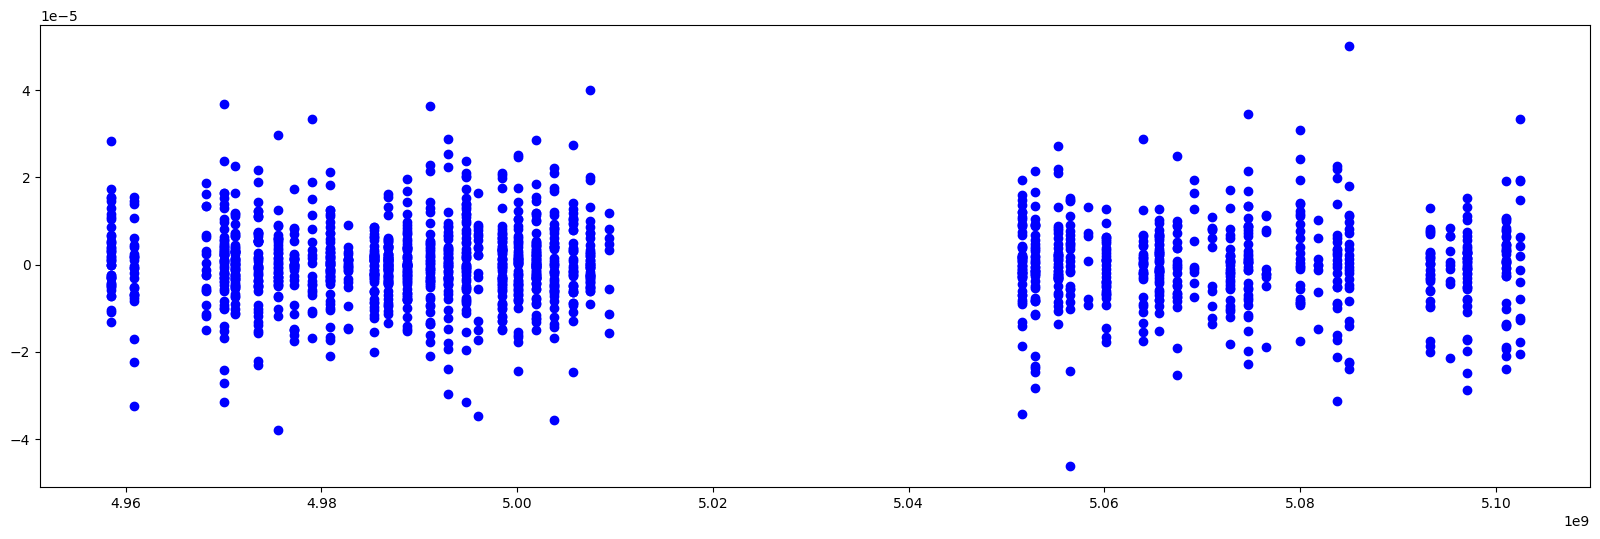

In [15]:
# compute average of all z_i
# combine all samples
z_mean = df_alpha.mean().values
plt.hist(z_mean, bins=30)

# check those with mean greater than 0.2 and call them outliers
outliers = np.where(z_mean > 0.1)[0]
print("Outlier indices:", outliers)

# plot residuals with outliers highlighted
plt.figure(figsize=(20, 6))
plt.scatter(toas, residuals, label='Residuals', color='blue')
plt.scatter(toas[outliers], residuals[outliers], label='Outliers', color='red')


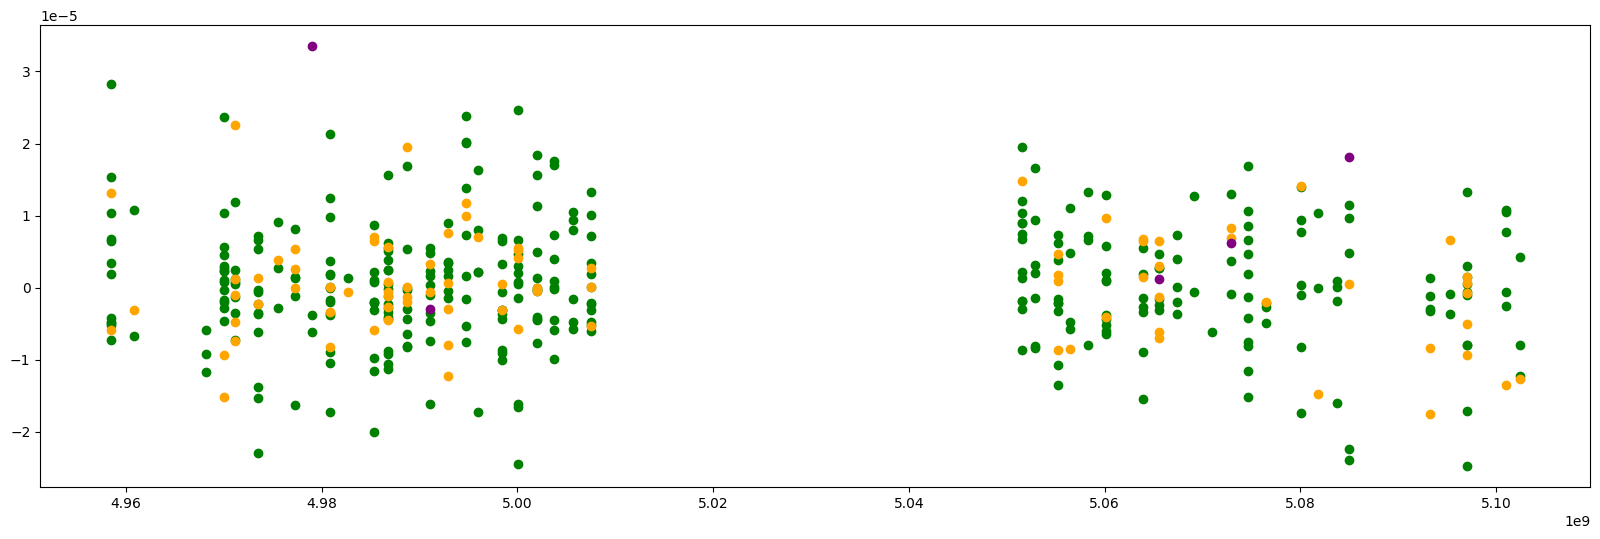

In [20]:
plt.figure(figsize=(20, 6))

close_to_threshold = np.where((z_mean > 0.009) & (z_mean < 0.011))[0]
plt.scatter(toas[close_to_threshold], residuals[close_to_threshold], label='Close to Threshold', color='green')

close_to_threshold_02 = np.where((z_mean > 0.019) & (z_mean < 0.021))[0]
plt.scatter(toas[close_to_threshold_02], residuals[close_to_threshold_02], label='Close to 0.02', color='orange')

# those close to 0.03
close_to_threshold_03 = np.where((z_mean > 0.029) & (z_mean < 0.031))[0]
plt.scatter(toas[close_to_threshold_03], residuals[close_to_threshold_03], label='Close to 0.03', color='purple')

# those close to 0.04
close_to_threshold_04 = np.where((z_mean > 0.039) & (z_mean < 0.041))[0]
plt.scatter(toas[close_to_threshold_04], residuals[close_to_threshold_04], label='Close to 0.04', color='red')